In [1]:
import os
from pathlib import Path
import glob
import json
import pretty_midi
import music21 as m21
from itertools import combinations
import numpy as np
import pandas as pd
import pretty_midi
import matplotlib.pyplot as plt
import seaborn as sns
import math
from tqdm import tqdm

from musical_statistics_visualization import *

/home/ubuntu/ugrip/andrew/StreamMUSE/.venv/lib/python3.10/site-packages/pretty_midi/instrument.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
dataset_paths = [
    # 'inputs/pop909_dataset/mel',
    # 'inputs/aria_unique_skyline_top2/mel',
    '../../../original_dataset/POP909-Dataset/POP909',
    '../../../original_dataset/aria-midi-v1-unique-ext/data',
    # 'outputs/everything_0721/pop909_dataset/fake_offline_script',
    # 'outputs/everything_0721/aria_unique_skyline_top2/fake_offline_script',
    # 'outputs/everything_0721/pop909_dataset/fake_offline_script_lantency2',
    # 'outputs/everything_0721/aria_unique_skyline_top2/fake_offline_script_lantency2',
    # 'outputs/everything_0721/pop909_dataset/real_offline_script',
    # 'outputs/everything_0721/aria_unique_skyline_top2/real_offline_script',
    # 'outputs/everything_0721/pop909_dataset/real_offline_Xinyue_new_script',
    # 'outputs/everything_0721/aria_unique_skyline_top2/real_offline_Xinyue_new_script',
]
statistics_file_names = [
    'collection_distribution_statistics.json',
    'collection_mean_statistics.json',
    'file_independent_statistics.json',
]

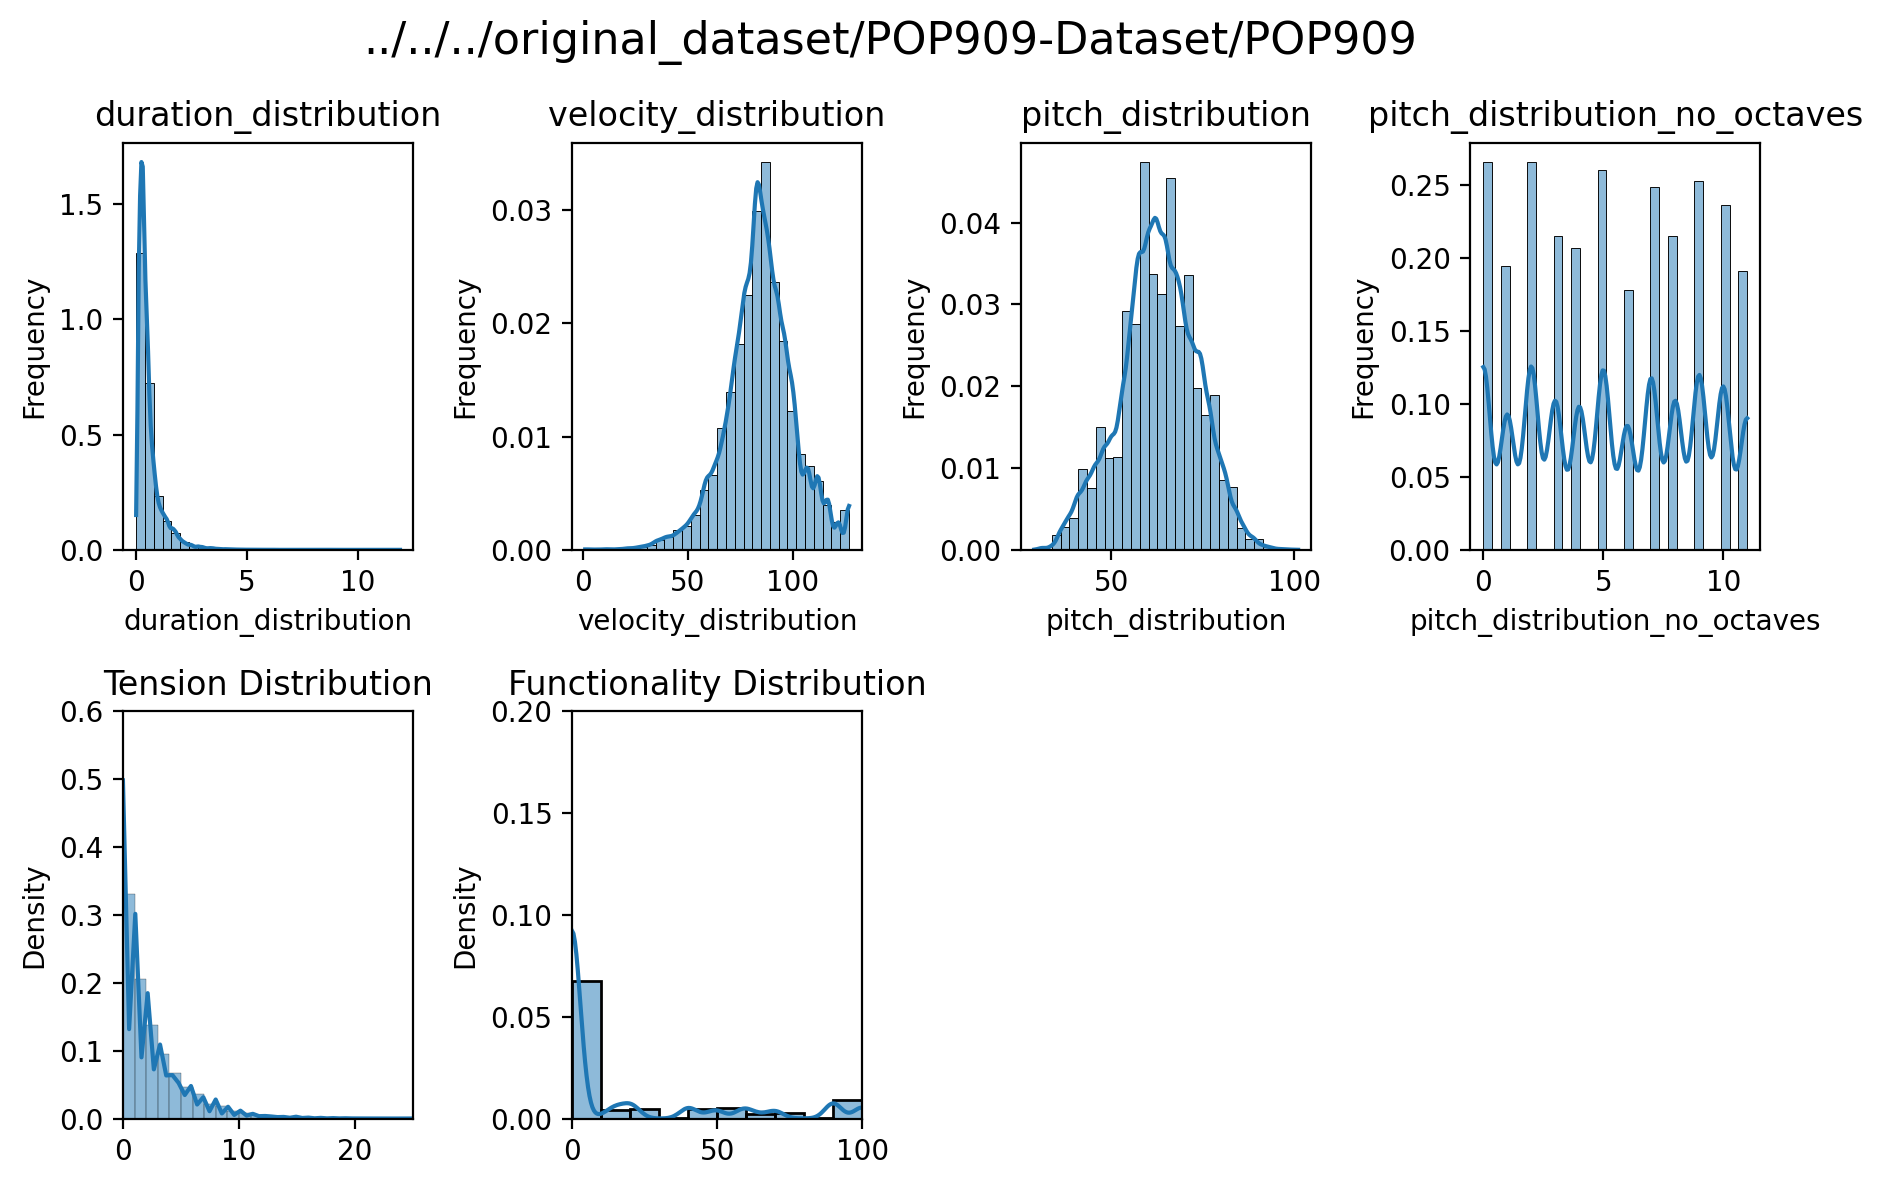

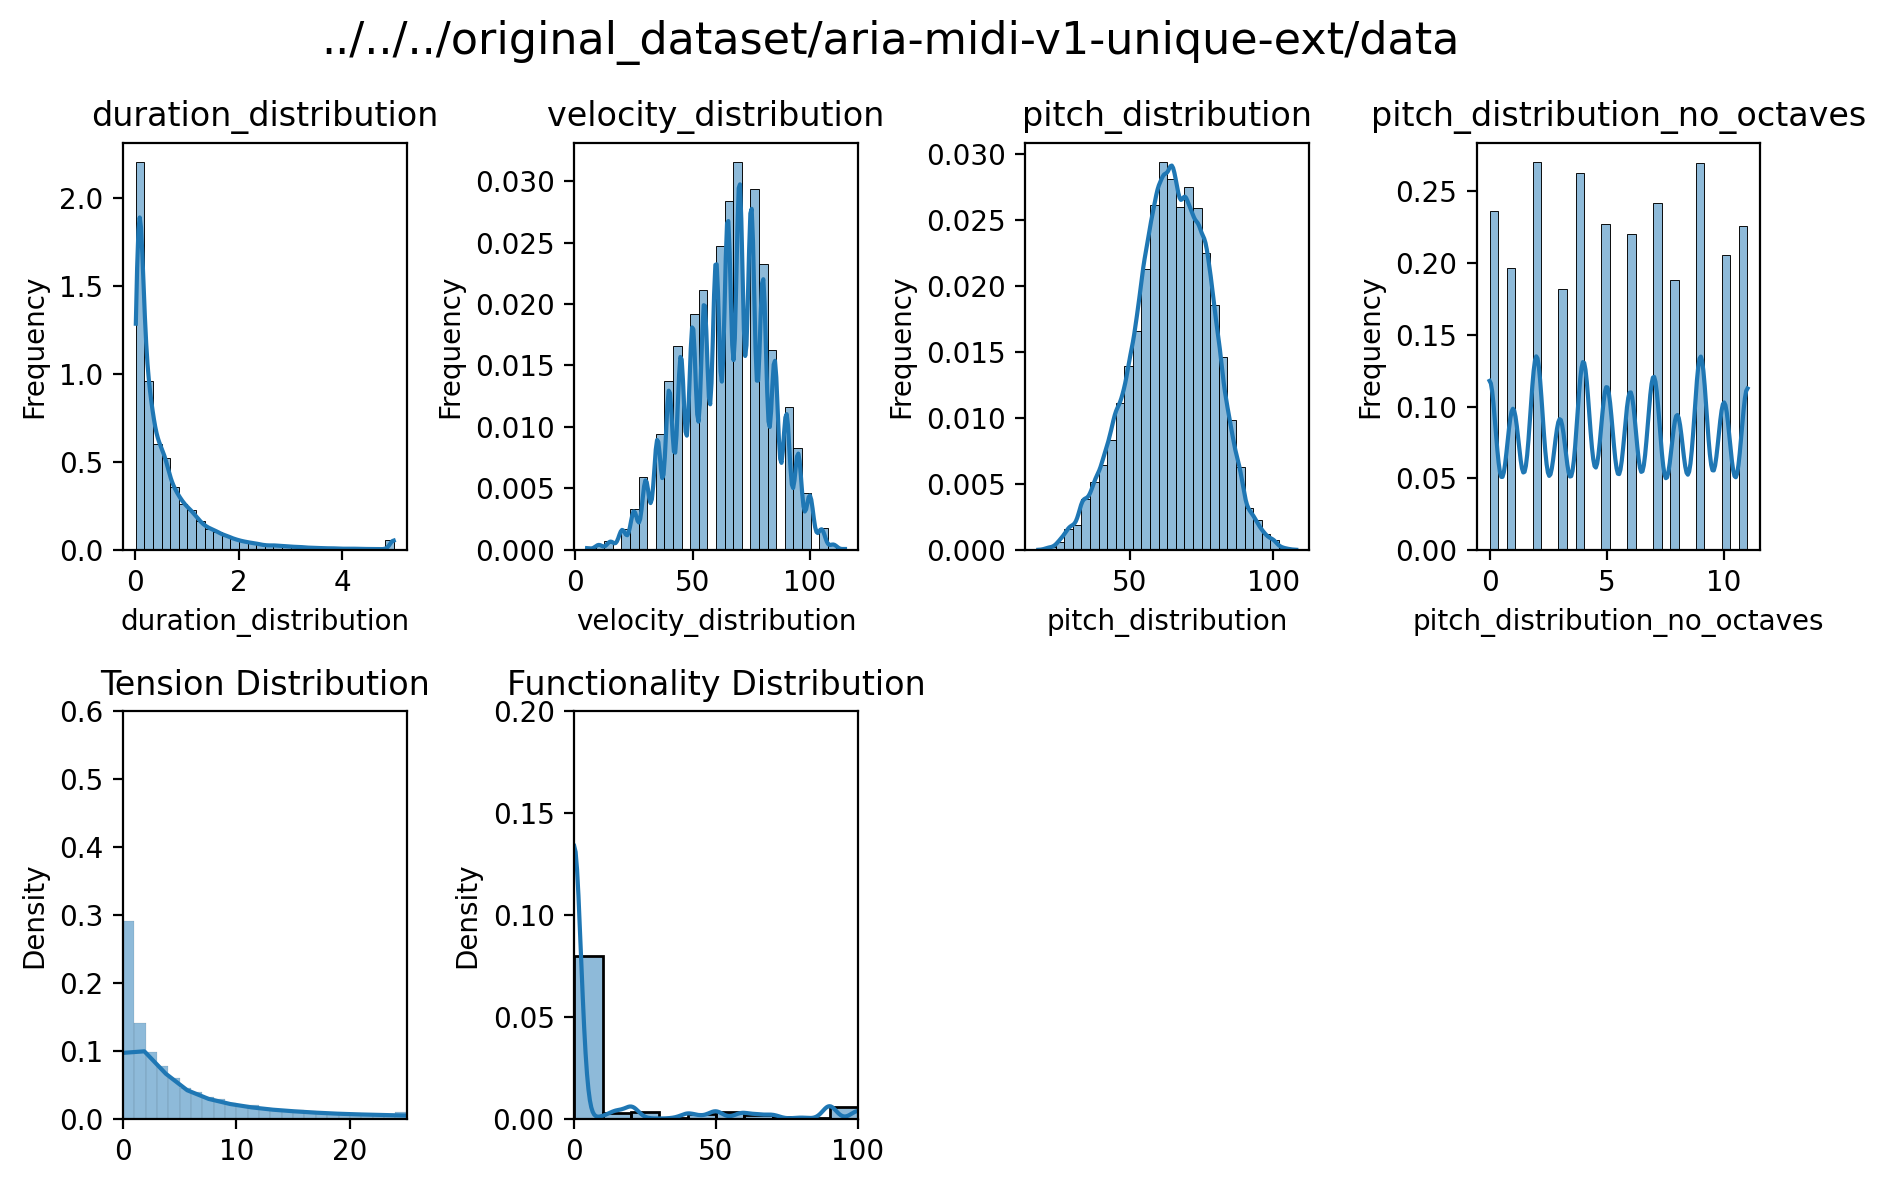

In [3]:
for i in range(len(dataset_paths)):
    path = Path(dataset_paths[i]) / statistics_file_names[0]

    distribution_histograms_collections(path, dataset_paths[i])

In [4]:
performance_paths = [
    'outputs/0722_full_run/fake_offline_script/pop909_dataset',
    'outputs/0722_full_run/fake_offline_script/aria_unique_skyline_top2',
    'outputs/0722_full_run/fake_offline_script_lantency2/pop909_dataset',
    'outputs/0722_full_run/fake_offline_script_lantency2/aria_unique_skyline_top2',
    'outputs/0722_full_run/real_offline_script/pop909_dataset',
    'outputs/0722_full_run/real_offline_script/aria_unique_skyline_top2',
    'outputs/0722_full_run/real_offline_Xinyue_new_script/pop909_dataset',
    'outputs/0722_full_run/real_offline_Xinyue_new_script/aria_unique_skyline_top2',
    'outputs/0722_full_run/real_offline_Xinyue_new_chord_script/pop909_dataset',
    # 'outputs/0722_full_run/real_offline_Xinyue_new_chord_script/aria_unique_skyline_top2',
]

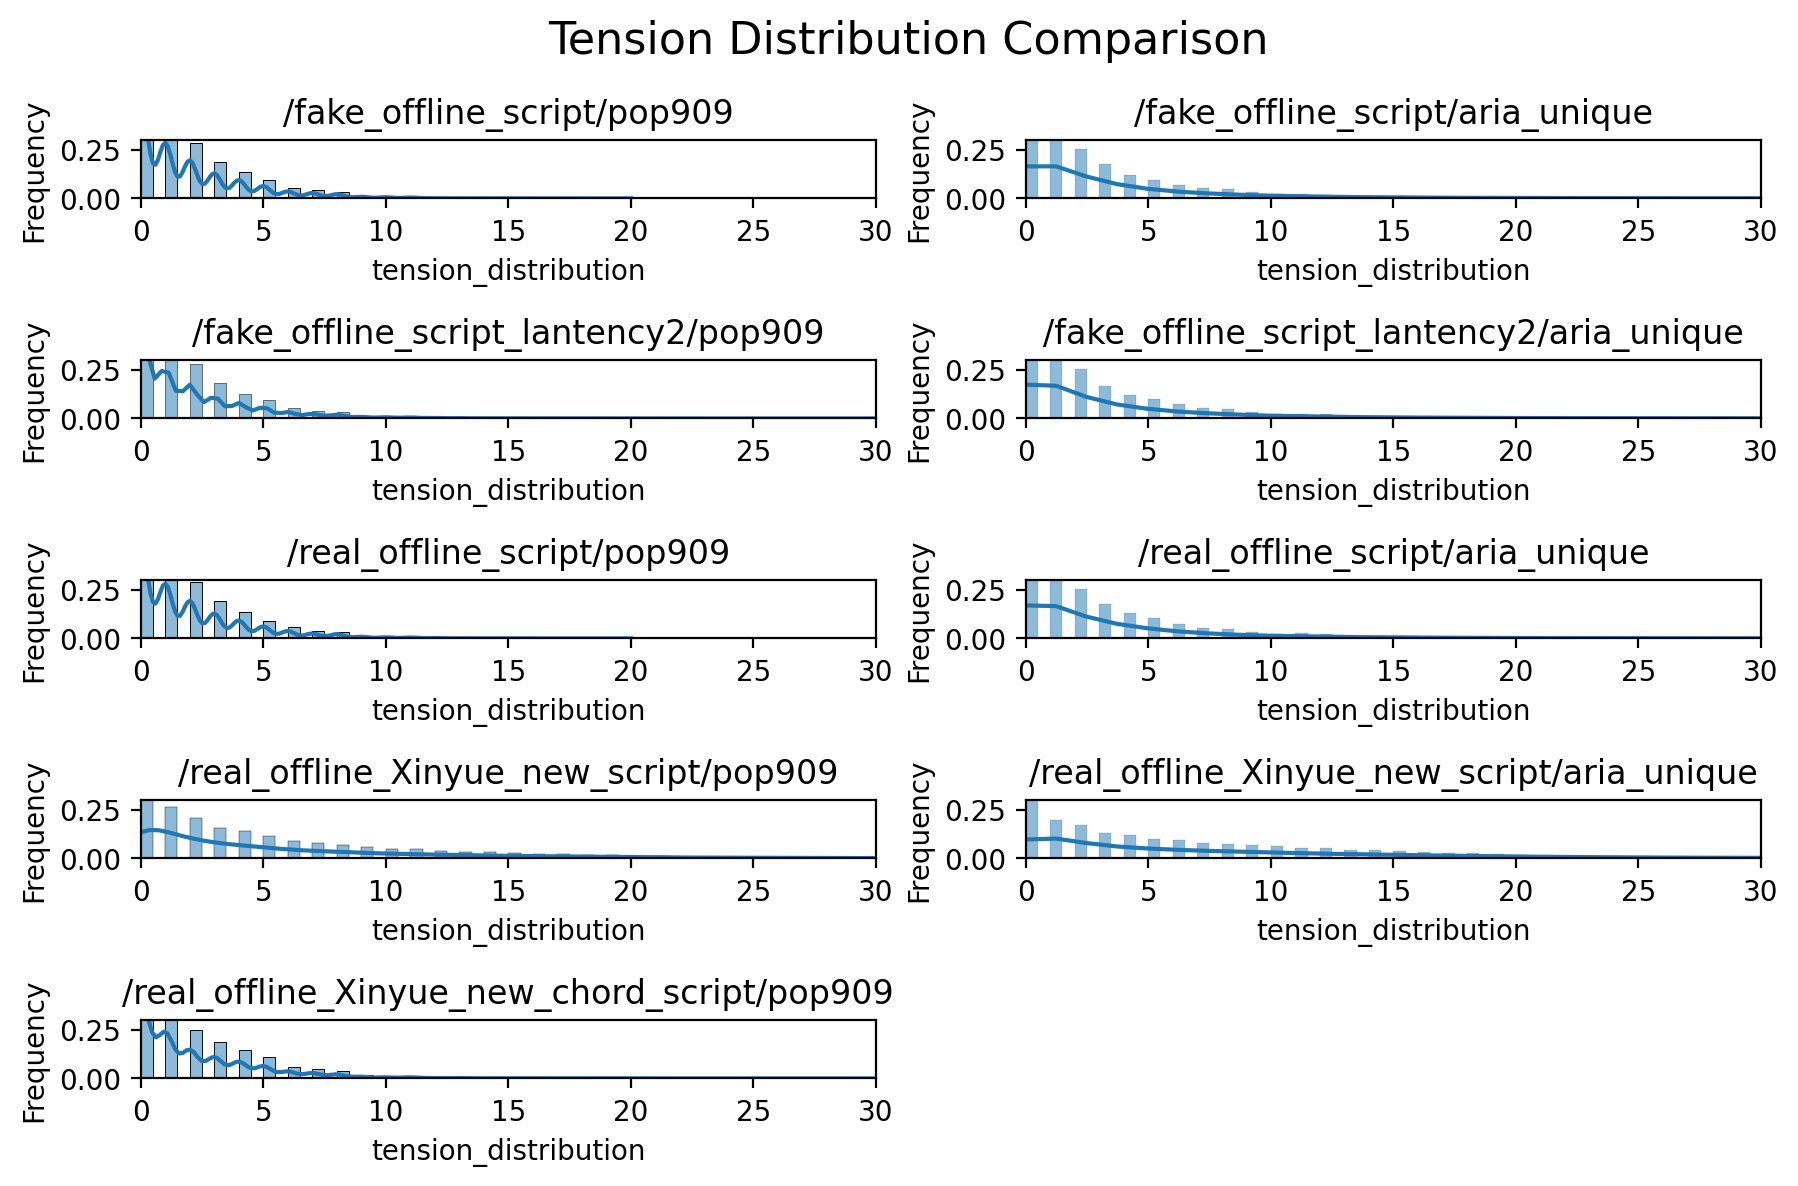

In [5]:
distribution_histograms_by_metric(
    performance_paths,
    'collection_distribution_statistics.json',
    'Tension Distribution Comparison',
    'tension_distribution',
    rows=5,
    cols=2,
    bins=np.linspace(0, 30, 61),
    xlim=(0, 30),
    ylim=(0, 0.3)
)

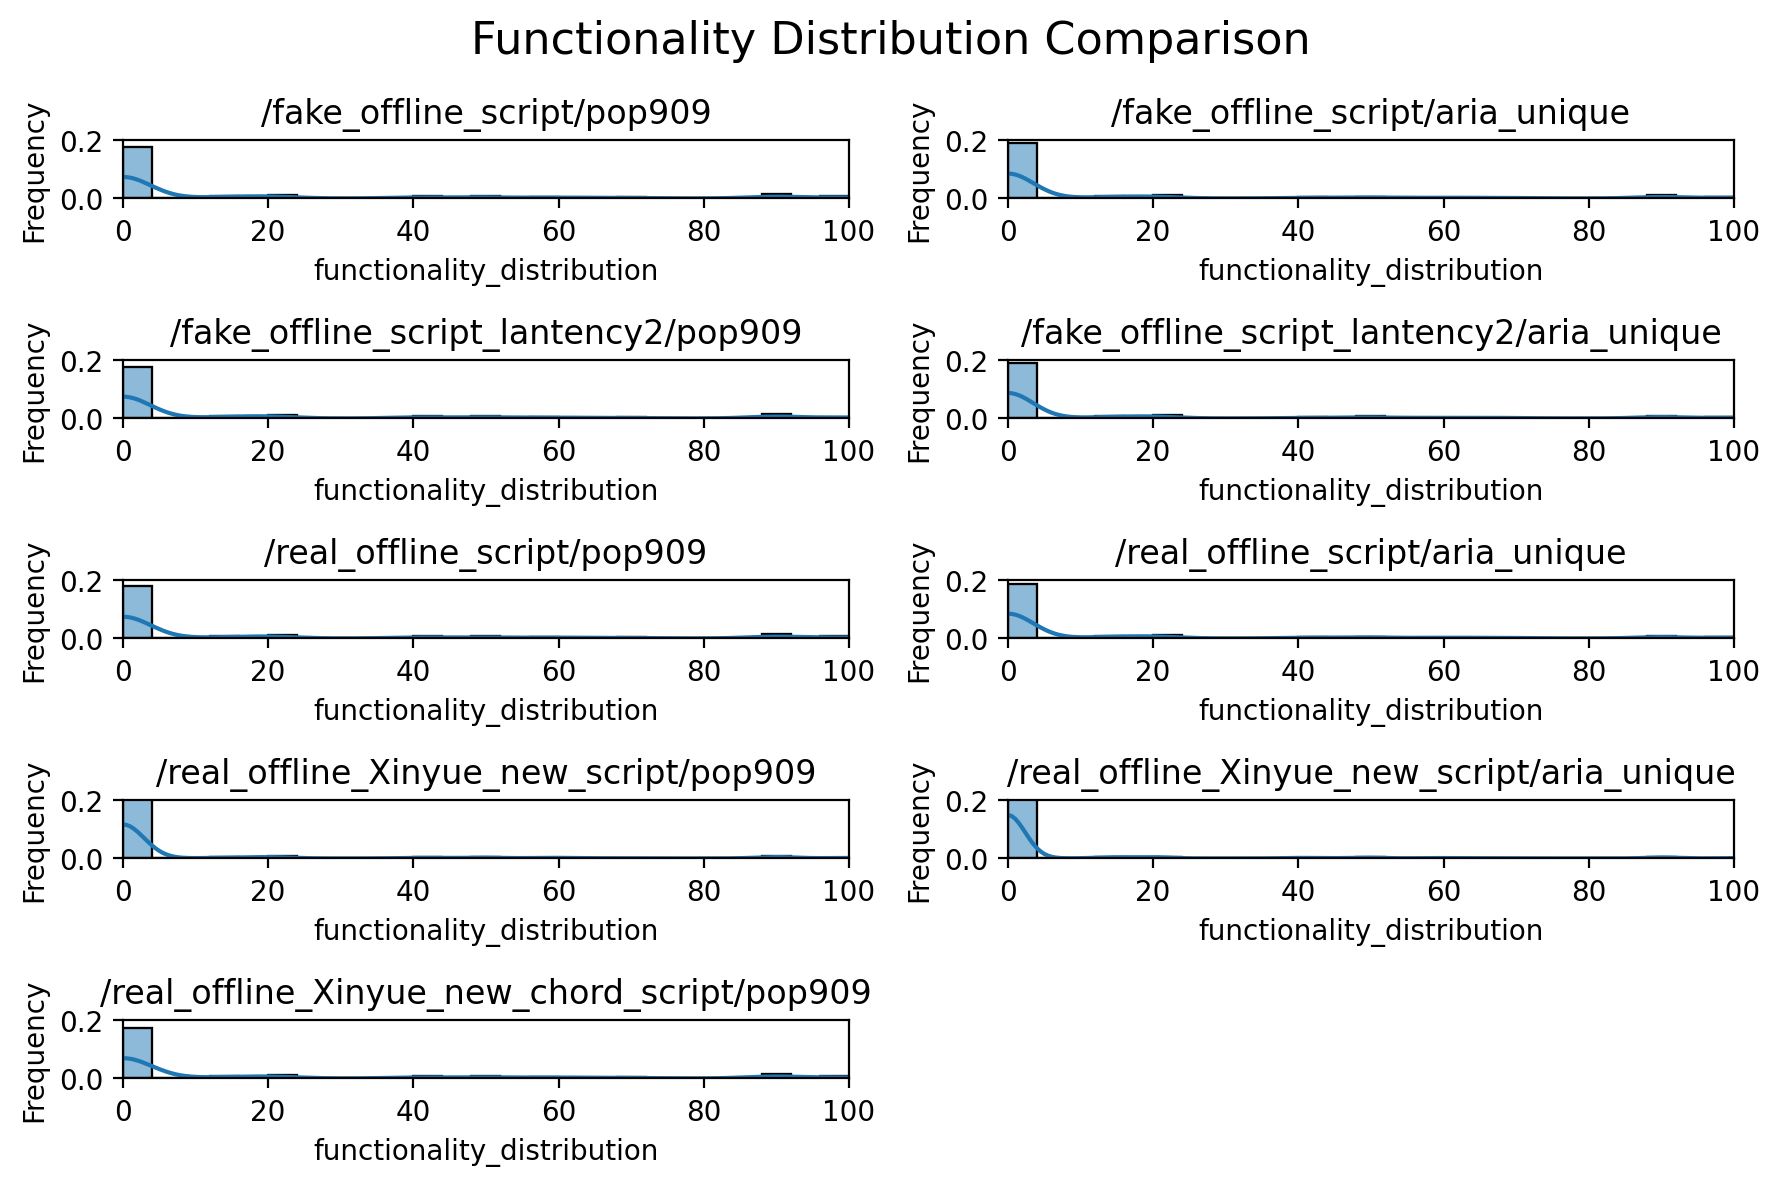

In [6]:
distribution_histograms_by_metric(
    performance_paths,
    'collection_distribution_statistics.json',
    'Functionality Distribution Comparison',
    'functionality_distribution',
    rows=5,
    cols=2,
    bins=np.linspace(0, 100, 26),
    ylim=(0, 0.2)
)

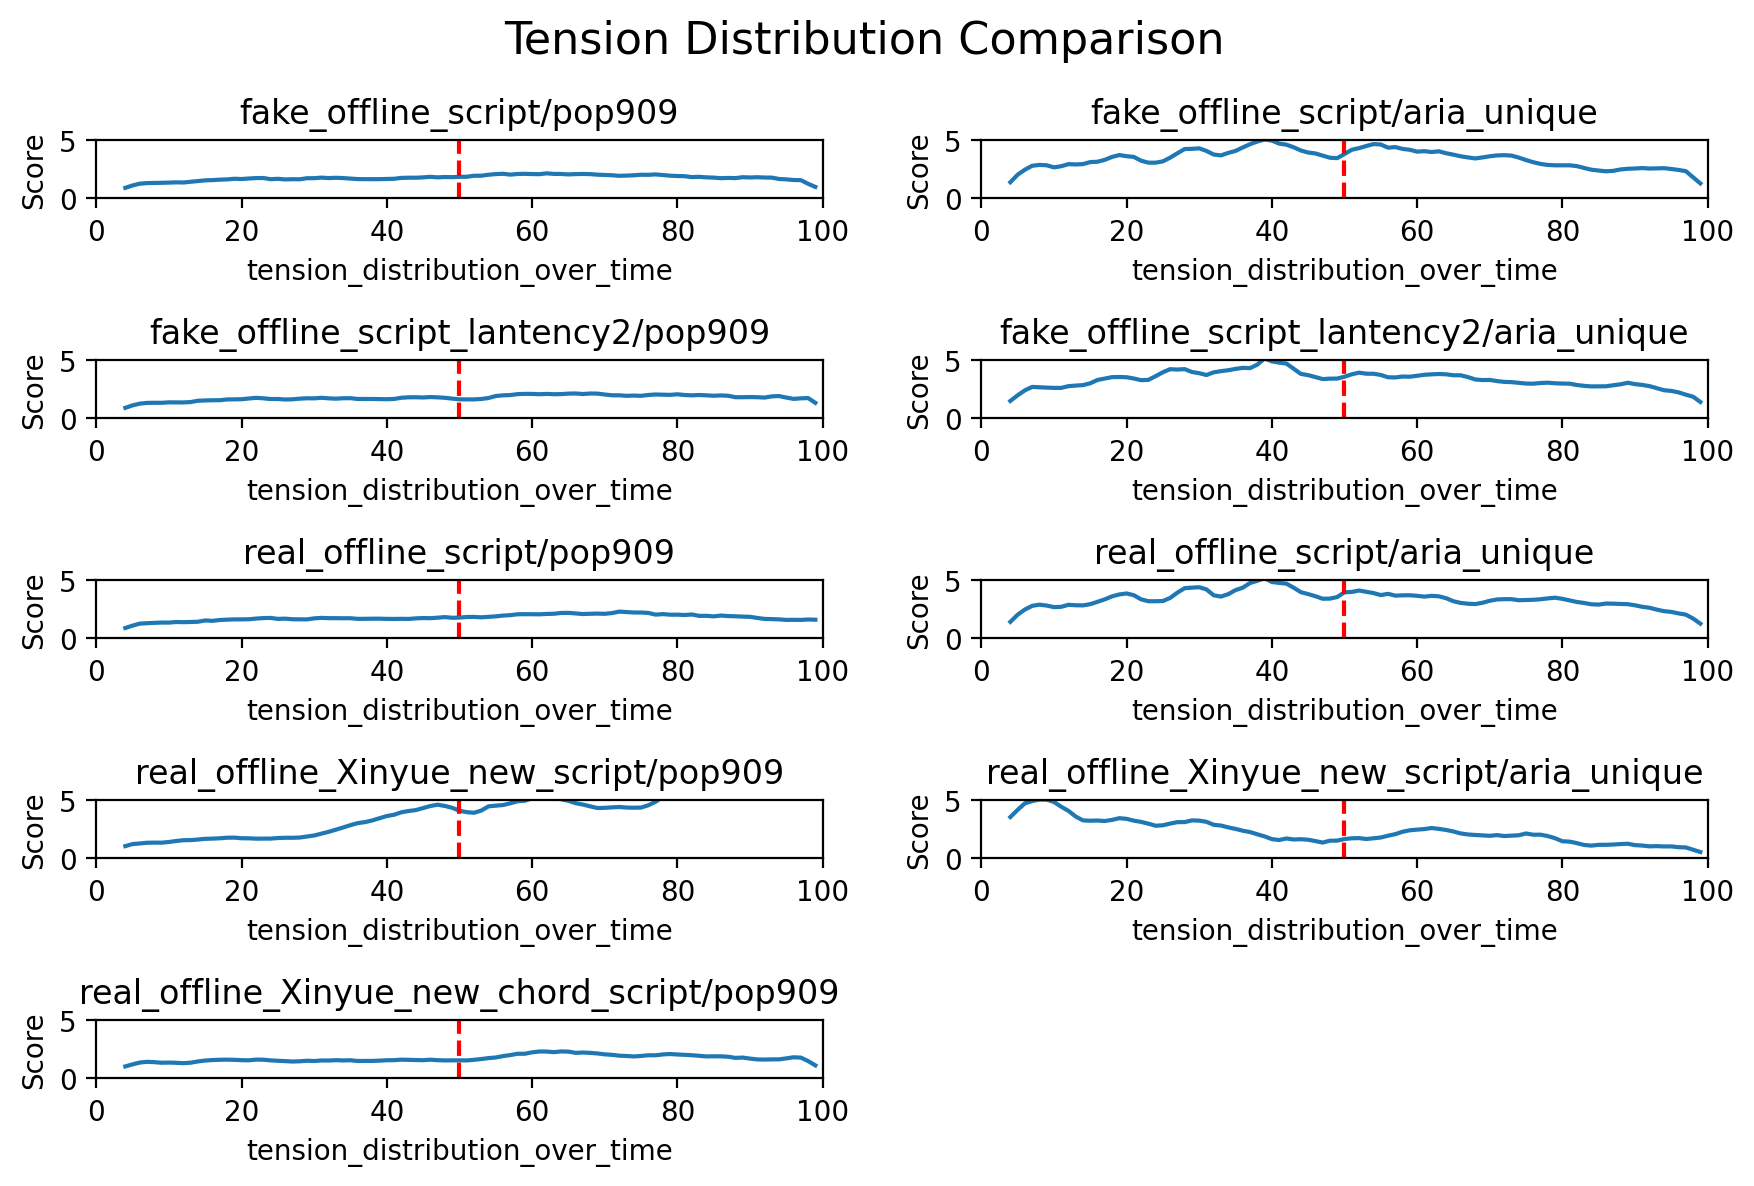

In [7]:
distribution_over_time_by_metric(
    file_paths=performance_paths,
    file_name='collection_distribution_statistics.json',
    title='Tension Distribution Comparison',
    metric='tension_distribution_over_time',
    rows=5,
    cols=2,
    ylim=(0, 5),
)

In [8]:
data_dict = json.load(open('outputs/0722_full_run/real_offline_Xinyue_new_script/pop909_dataset/collection_distribution_statistics.json', 'r'))
df = pd.DataFrame(data_dict['tension_distribution_over_time']).rolling(window=5).mean().reset_index()
df

,index,0
0,0,NaN
1,1,NaN
2,2,NaN
3,3,NaN
4,4,1.053198
...,...,...
95,95,6.144480
96,96,6.074180
97,97,6.039025
98,98,6.130200


In [9]:
data_dict = json.load(open('outputs/0722_full_run/real_offline_script/pop909_dataset/collection_distribution_statistics.json', 'r'))
df2 = pd.DataFrame(data_dict['tension_distribution_over_time']).rolling(window=5).mean().reset_index()
df2

,index,0
0,0,NaN
1,1,NaN
2,2,NaN
3,3,NaN
4,4,0.892833
...,...,...
95,95,1.583333
96,96,1.592167
97,97,1.585000
98,98,1.619667
